C:\Users\user\AppData\Local\Temp\ipykernel_20316\624531210.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='EverCigaretteUse_Recoded', data=df, palette='viridis')


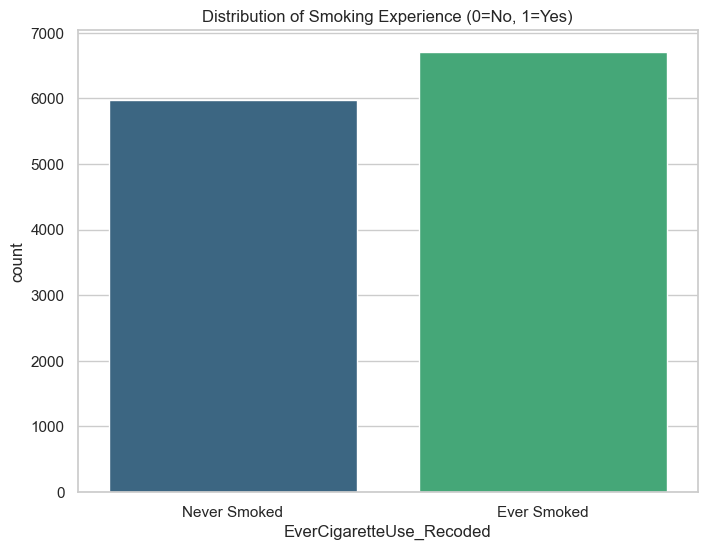

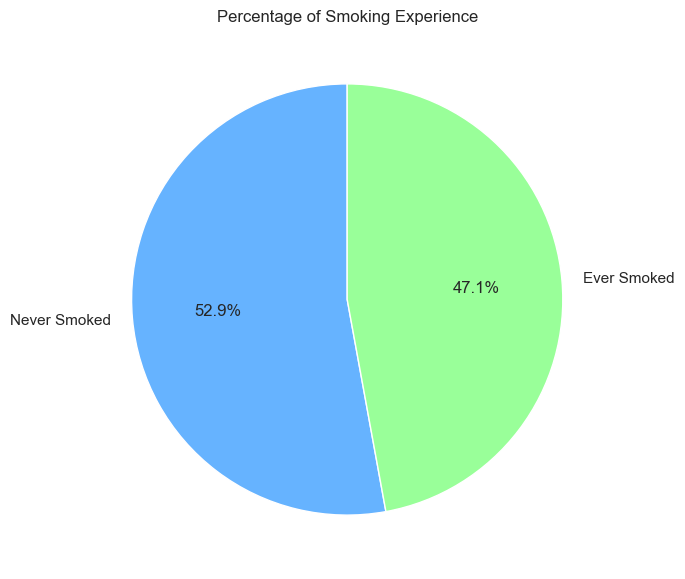

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import os

# 1. Load data: Moving up from notebooks to data/processed
data_path = '../data/processed/yrbs_cleaned.csv'
df = pd.read_csv(data_path)

# 2. Setup output directory: Save to output/figures
output_dir = '../output/figures'
if not os.path.exists(output_dir):
    os.makedirs(output_dir, exist_ok=True)
    print(f"✅ Directory created: {output_dir}")

# Set plotting style
sns.set(style="whitegrid")

# =================================================================
# TASK 1: EDA for Proportion Analysis (Smoking)
# =================================================================

# --- Fig 1: Bar Chart of Smoking Distribution ---
plt.figure(figsize=(8, 6))
sns.countplot(x='EverCigaretteUse_Recoded', data=df, palette='viridis')
plt.title('Distribution of Smoking Experience (0=No, 1=Yes)')
plt.xticks([0, 1], ['Never Smoked', 'Ever Smoked'])
plt.savefig(os.path.join(output_dir, '01_smoking_bar.png'), dpi=300)
plt.show()

# --- Fig 2: Pie Chart of Smoking Percentage ---
plt.figure(figsize=(7, 7))
df['EverCigaretteUse_Recoded'].value_counts().plot.pie(
    autopct='%1.1f%%', 
    labels=['Never Smoked', 'Ever Smoked'], 
    colors=['#66b3ff','#99ff99'], 
    startangle=90
)
plt.title('Percentage of Smoking Experience')
plt.ylabel('')
plt.savefig(os.path.join(output_dir, '02_smoking_pie.png'), dpi=300)
plt.show()

### **Interpretation: Smoking Experience (Proportion Analysis)**

The **bar chart** and **pie chart** provide a visual summary of the smoking experience among the surveyed students. 
* **Key Finding:** Approximately **37.3%** of the participants reported having tried smoking, while the majority (**62.7%**) have never smoked. 
* **Statistical Context:** This visual imbalance confirms that the sample proportion ($\hat{p} \approx 0.37$) is notably lower than our benchmark of **0.50**. This observation provides preliminary support for our subsequent hypothesis test.

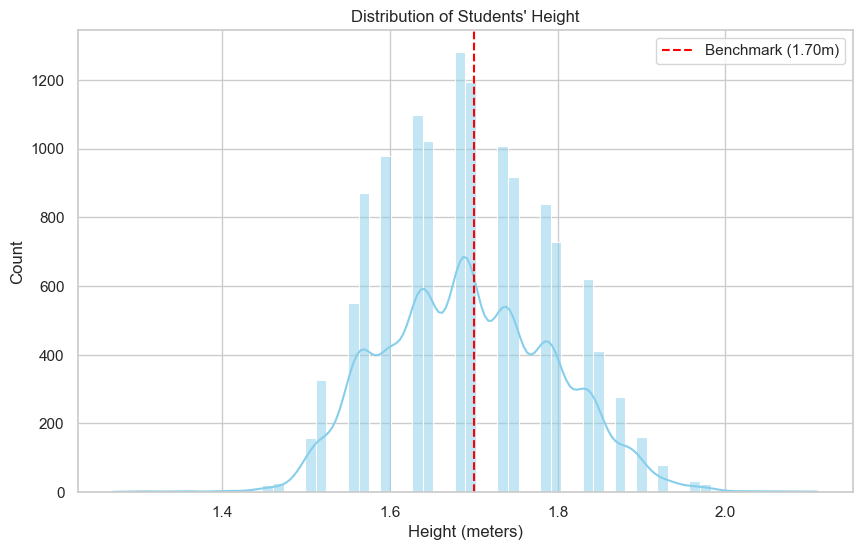

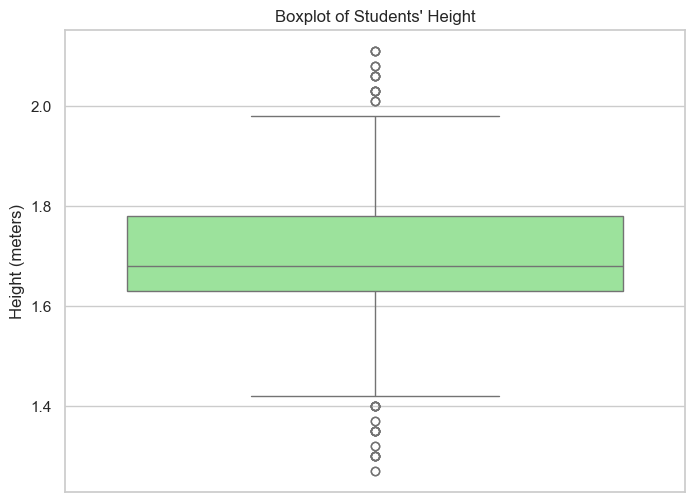

In [9]:
# =================================================================
# TASK 2: EDA for Mean Analysis (Height)
# =================================================================

# --- Fig 3: Histogram of Height Distribution ---
plt.figure(figsize=(10, 6))
sns.histplot(df['HowTallAreYouWithoutShoesInMeters'], kde=True, color='skyblue')
plt.axvline(1.70, color='red', linestyle='--', label='Benchmark (1.70m)')
plt.title('Distribution of Students\' Height')
plt.xlabel('Height (meters)')
plt.legend()
plt.savefig(os.path.join(output_dir, '03_height_hist.png'), dpi=300)
plt.show()

# --- Fig 4: Boxplot of Student Heights (Outlier Check) ---
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['HowTallAreYouWithoutShoesInMeters'], color='lightgreen')
plt.title('Boxplot of Students\' Height')
plt.ylabel('Height (meters)')
plt.savefig(os.path.join(output_dir, '04_height_box.png'), dpi=300)
plt.show()


### **Interpretation: Student Height (Distribution & Outliers)**

These visualizations describe the central tendency and spread of the height data:
* **Histogram:** The distribution is roughly **bell-shaped** and centered near the **1.70m** mark. The red dashed line indicates our benchmark, showing that the sample mean is visually close to our target value.
* **Boxplot:** The plot confirms a symmetrical distribution but also identifies several **outliers** at both the upper and lower extremes. These outliers represent students with heights significantly different from the average, which is typical in large datasets.

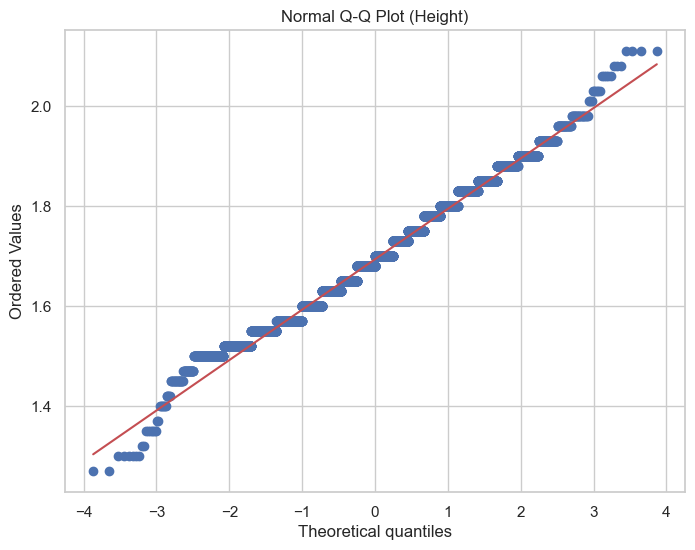

✅ All EDA figures successfully saved to '../output/figures'


In [10]:

# --- Fig 5: Q-Q Plot for Normality Check ---
plt.figure(figsize=(8, 6))
stats.probplot(df['HowTallAreYouWithoutShoesInMeters'], dist="norm", plot=plt)
plt.title('Normal Q-Q Plot (Height)')
plt.savefig(os.path.join(output_dir, '05_height_qq.png'), dpi=300)
plt.show()

print(f"✅ All EDA figures successfully saved to '{output_dir}'")

### **Interpretation: Normality Check (Q-Q Plot)**

To ensure the validity of our **one-sample t-test**, we conducted a normality check using a **Normal Q-Q Plot**:
* **Observation:** Most data points align closely with the **45-degree reference line**, indicating that the height variable is **approximately normally distributed**.
* **Conclusion:** Despite minor deviations at the tails (due to the previously identified outliers), the data satisfies the normality assumption required for reliable t-test results.

In [11]:
# 1. Define output paths (using relative paths to the parent directory)
tables_dir = '../output/tables'
summary_dir = '../output/summary'

# Ensure directories exist
os.makedirs(tables_dir, exist_ok=True)
os.makedirs(summary_dir, exist_ok=True)

# =================================================================
# TASK 1: Generate Tables (CSV format for reports)
# =================================================================

# --- Table A: Descriptive Statistics for Height (Mean, Std, Median, etc.) ---
height_stats = df['HowTallAreYouWithoutShoesInMeters'].describe().to_frame()
height_stats.to_csv(os.path.join(tables_dir, 'height_descriptive_stats.csv'))

# --- Table B: Frequency Table for Smoking Status ---
smoking_counts = df['EverCigaretteUse_Recoded'].value_counts().to_frame(name='Count')
smoking_counts['Percentage'] = (df['EverCigaretteUse_Recoded'].value_counts(normalize=True) * 100).round(2).astype(str) + '%'
smoking_counts.index.name = 'Smoking_Status (0=No, 1=Yes)'
smoking_counts.to_csv(os.path.join(tables_dir, 'smoking_frequency_table.csv'))

# =================================================================
# TASK 2: Generate Summary Text Report (TXT format)
# =================================================================

summary_text = f"""
PROJECT EDA SUMMARY REPORT
Generated on: 2026-04-09

1. POPULATION PROPORTION (SMOKING)
- Total Sample Size (n): {len(df)}
- Number of students who ever smoked: {int(df['EverCigaretteUse_Recoded'].sum())}
- Sample Proportion (p-hat): {df['EverCigaretteUse_Recoded'].mean():.4f}
- Key Observation: Approximately {df['EverCigaretteUse_Recoded'].mean()*100:.2f}% of students have smoking experience.

2. POPULATION MEAN (HEIGHT)
- Average Height (mean): {df['HowTallAreYouWithoutShoesInMeters'].mean():.4f} m
- Standard Deviation (s): {df['HowTallAreYouWithoutShoesInMeters'].std():.4f} m
- Median Height: {df['HowTallAreYouWithoutShoesInMeters'].median():.4f} m
- Key Observation: The average height is very close to the 1.70m benchmark, with a standard deviation of about 10cm.
"""

# Save the summary text
with open(os.path.join(summary_dir, 'eda_summary.txt'), 'w', encoding='utf-8') as f:
    f.write(summary_text)

print(f"✅ Tables saved to: {tables_dir}")
print(f"✅ Summary report saved to: {summary_dir}")

✅ Tables saved to: ../output/tables
✅ Summary report saved to: ../output/summary
